<a href="https://colab.research.google.com/github/tatyanakrivonogova/machine-learning-methods/blob/master/%D0%91%D0%BB%D0%BE%D0%BA_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Кластеризация

## DBSCAN
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) – алгоритм кластеризации, основанный на плотности. Он выделяет кластеры как области с высокой плотностью объектов, разделённые областями с низкой плотностью. Не требует указания числа кластеров, может находить кластеры произвольной формы и идентифицировать шумовые точки (объекты, не принадлежащие ни одному кластеру).

### Используемые библиотеки

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

### Датасет

In [32]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
print('Первые 5 строк датасета:')
print(df.head())
print('\nРазмер:', X.shape)

Первые 5 строк датасета:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Размер: (150, 4)


### Предварительная обработка датасета

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Тепловая карта

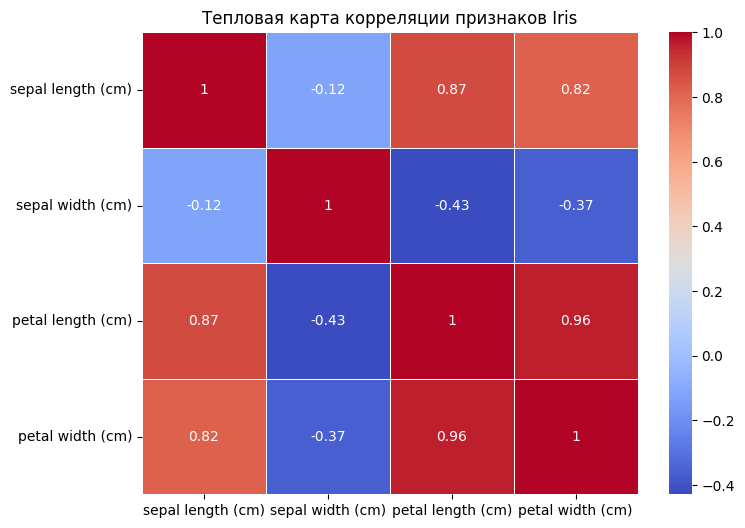

In [34]:
plt.figure(figsize=(8,6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляции признаков Iris')
plt.show()

### Обучение модели

In [35]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(X_scaled)

DBSCAN()

### Прогнозы модели

In [36]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score

labels = dbscan.labels_
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print('Метки кластеров для первых 10 объектов:', labels[:10])
print('\nУникальные метки:', unique_labels)
print('Количество кластеров (без шума):', n_clusters)
print('Количество шумовых точек:', n_noise)
print('\nРаспределение по кластерам:')
print(pd.Series(labels).value_counts().sort_index())

if n_clusters >= 2 and n_noise < len(labels):
    mask = labels != -1
    sil = silhouette_score(X_scaled[mask], labels[mask])
else:
    sil = np.nan
    print('Предупреждение: недостаточно точек для расчёта силуэта (нужно минимум 2 кластера без шума)')

ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ari = adjusted_rand_score(y, labels)
nmi = normalized_mutual_info_score(y, labels)

print(f"{'Метрика':<25} {'DBSCAN':>15}")
print(f"{'Silhouette (без шума)':<25} {sil:>15.4f}" if not np.isnan(sil) else f"{'Silhouette (без шума)':<25} {'N/A':>15}")
print(f"{'Calinski-Harabasz':<25} {ch:>15.2f}")
print(f"{'Davies-Bouldin':<25} {db:>15.4f}")
print(f"{'Adjusted Rand Index':<25} {ari:>15.4f}")
print(f"{'NMI':<25} {nmi:>15.4f}")

Метки кластеров для первых 10 объектов: [0 0 0 0 0 0 0 0 0 0]

Уникальные метки: {np.int64(0), np.int64(1), np.int64(-1)}
Количество кластеров (без шума): 2
Количество шумовых точек: 34

Распределение по кластерам:
-1    34
 0    45
 1    71
Name: count, dtype: int64
Метрика                            DBSCAN
Silhouette (без шума)              0.6559
Calinski-Harabasz                   84.51
Davies-Bouldin                     7.1241
Adjusted Rand Index                0.4421
NMI                                0.5114


### Графики выходных результатов

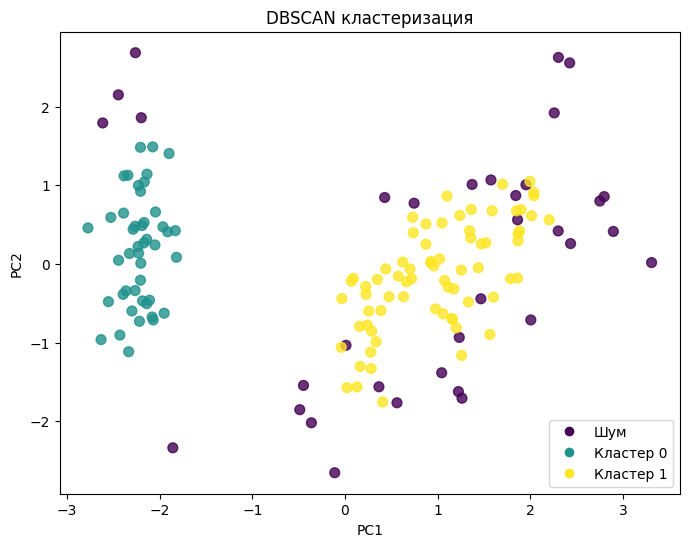

In [37]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=50, alpha=0.8)
plt.title('DBSCAN кластеризация')
plt.xlabel('PC1')
plt.ylabel('PC2')

handles = []
for label in np.unique(labels):
    color = scatter.cmap(scatter.norm(label))
    handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=f'Кластер {label}' if label != -1 else 'Шум'))
plt.legend(handles=handles)

plt.show()